# White noise and the CP/HD separation

**Question.** The baseline astrometric noise is $\sigma=1$ mas. Does lowering it to 0.1, 0.01 or 0.001 mas change the separation between the CP and HD SNR curves?

**The short answer is in two parts, and this notebook tests both.**

1. **As functions of $r=P_{gw}(f_l)/P_n$, the curves do not depend on $\sigma$ at all.** The noise enters the covariance only through $P_n$, and every term can be written in units of $P_n$. Section 2 checks this with covariances built in physical units.
2. **What changes is where the real signal sits on those curves.** $P_n=2\sigma^2\Delta t$, so the physical operating point $r_{\rm phys}\propto1/\sigma^2$ moves 100 times higher for every factor of 10 in $\sigma$. The separation at the operating point stays at its weak-signal value until $r_{\rm phys}$ reaches the saturation region, and then it collapses. Sections 3 to 5 measure this.

**Conventions.** Uses `main.py` and `hd_full_matrix_snr.py` from the same folder (`POL_FACTOR`, `NORMALIZED_GAMMA`, cadence, $T_{\rm obs}$ and $A_{gw}$ all come from `main.py`). HD is solved directly (dense) for $N=40$. Section 5 repeats the operating-point numbers at the production $N$ with the pipeline's matrix-free solver.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

sys.path.insert(0, os.getcwd())
import main as M
import hd_full_matrix_snr as H

# main.py selects the Agg backend for Slurm; switch back to inline plots here.
%matplotlib inline

c, F = M.POL_FACTOR, M.gamma_scale_factor()
SIGMAS_MAS = [1.0, 0.1, 0.01, 0.001]
N_DENSE, FOV = 40, M.FIELD_SIZE_DEG
RUN_PRODUCTION_N = True          # Section 5; about 70 s at N=500 on one core
N_PROD = M.N_STARS

COL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
LS  = ["-", "--", "-.", ":"]
MK  = ["o", "s", "^", "D"]
CP_COL, HD_COL = COL[0], COL[1]
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9, "legend.frameon": False,
})
print(f"POL_FACTOR={c}, NORMALIZED_GAMMA={M.NORMALIZED_GAMMA}, FoV={FOV} deg, A_gw={M.A_gw:g}")

POL_FACTOR=2.0, NORMALIZED_GAMMA=True, FoV=10 deg, A_gw=1e-15


In [2]:
def noise_psd(sigma_mas):
    # P_n = 2 sigma^2 dt, sigma in mas -> rad^2/Hz.
    s = (sigma_mas * u.mas).to(u.rad).value
    return 2.0 * s**2 * M.dt_seconds

def p_gw(A):
    # P_gw(f_l) for amplitude A, same expression as main.py.
    return (np.asarray(A)**2 / (12 * np.pi**2)) * (M.f_l / M.f_yr)**(-4/3) / M.f_l

def make_field(N, fov, seed=M.RANDOM_SEED):
    st = M.build_star_positions(None, N, fov, seed)
    th = M.pairwise_theta(st)
    lmin, lmax = M.compute_ell_limits(th, fov)
    # Larger batches than main.GAMMA_BATCH_SIZE: same values, about 4x faster at N=500.
    return M.gamma_parallel_matrix(th, lmin, lmax, batch_size=20000), M.cp_single_star_gamma(lmin, lmax), lmin, lmax

def hd_rho(gam, g0, r_arr):
    # Full-covariance HD SNR by direct dense solve of M(r) y = 1, rho^2 = 2 * sum(y).
    _, A, B, D = H.build_HD_matrices(gam, g0)
    one = np.ones(A.shape[0])
    return np.array([np.sqrt(2 * np.linalg.solve(A + B / r + D / r**2, one).sum()) for r in np.atleast_1d(r_arr)])

## 1. Where the physical signal sits for each noise level

In [3]:
rows = []
print(f"{'sigma [mas]':>12} {'P_n [rad^2/Hz]':>15} {'r_phys':>10} {'r_phys / r_phys(1 mas)':>23}")
for s in SIGMAS_MAS:
    Pn = noise_psd(s); rp = M.P_gw_fl / Pn
    rows.append((s, Pn, rp))
    print(f"{s:12g} {Pn:15.3e} {rp:10.2e} {rp / rows[0][2]:23.0f}")
R_PHYS = {s: rp for s, _, rp in rows}
assert np.isclose(R_PHYS[1.0], M.PHYSICAL_RATIO), "1 mas row should reproduce main.PHYSICAL_RATIO"

 sigma [mas]  P_n [rad^2/Hz]     r_phys  r_phys / r_phys(1 mas)
           1       8.462e-14   5.86e-11                       1
         0.1       8.462e-16   5.86e-09                     100
        0.01       8.462e-18   5.86e-07                   10000
       0.001       8.462e-20   5.86e-05                 1000000


## 2. Check: in $r$, the curves are independent of $\sigma$

The covariances are built here in **physical units**, without using the pipeline's $r$ parametrization. The amplitude $A_{gw}$ is swept, and $\sigma$ enters only through $P_n$. A small field ($N=12$) keeps the HD pair matrix small.

- **CP:** $\tilde C_{ab}=cF P_{gw}\Gamma_{ab}+P_n\delta_{ab}$, $C_{ab}=f_l^{14/3}|\tilde C_{ab}|^2/F^2$, $\rho^2=P_{gw}^2 f_l^{14/3}\,\mathbf 1^TC^{-1}\mathbf 1$.
- **HD:** $P_{ab}=cFP_{gw}\Gamma_{ab}$, $P_{aa}=P_n+cFP_{gw}\gamma_0$, $C_{ab,cd}=(P_{ac}P_{bd}+P_{ad}P_{bc})/(F_{ab}F_{cd})$ with $F_{ab}=F\Gamma_{ab}$, $\rho^2=2P_{gw}^2\,\mathbf 1^TC^{-1}\mathbf 1$.

The left panels plot against $A_{gw}$, and the curves for different $\sigma$ are displaced from each other. The right panel plots the same numbers against $r=P_{gw}/P_n$.

sigma=0.1 mas: max |rho/rho(1 mas) - 1| at equal r:  CP 5.4e-14,  HD 5.9e-08
sigma=0.01 mas: max |rho/rho(1 mas) - 1| at equal r:  CP 4.1e-13,  HD 2.2e-08
sigma=0.001 mas: max |rho/rho(1 mas) - 1| at equal r:  CP 1.1e-13,  HD 1.1e-08


physical-units build vs pipeline functions (1 mas):  CP 8.9e-14,  HD 1.4e-07


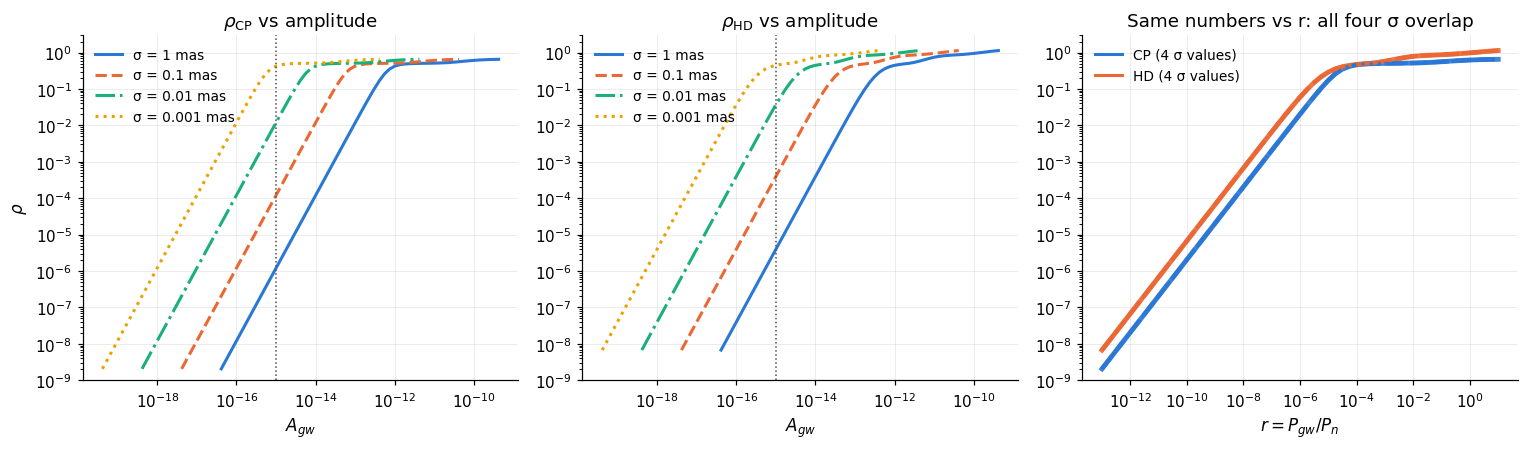

In [4]:
N_SM = 12
gS, g0S, lminS, lmaxS = make_field(N_SM, FOV)
GamS = M.cp_gamma_matrix(gS, g0S)
pairs = np.array(np.triu_indices(N_SM, 1)).T
a_, b_ = pairs[:, 0], pairs[:, 1]
fl = M.f_l

def cp_phys(Pgw, Pn):
    Ct = c * F * Pgw * GamS + Pn * np.eye(N_SM)
    C = fl**(14/3) * Ct**2 / F**2
    sc = C.max()                                            # rescale before solving
    return np.sqrt(Pgw**2 * fl**(14/3) / sc * np.linalg.solve(C / sc, np.ones(N_SM)).sum())

def hd_phys(Pgw, Pn):
    P = c * F * Pgw * GamS.copy(); np.fill_diagonal(P, Pn + c * F * Pgw * g0S)
    Fab = F * GamS[a_, b_]
    C = (P[a_][:, a_] * P[b_][:, b_] + P[a_][:, b_] * P[b_][:, a_]) / np.outer(Fab, Fab)
    sc = C.max()
    return np.sqrt(2 * Pgw**2 / sc * np.linalg.solve(C / sc, np.ones(len(a_))).sum())

r_grid = np.logspace(-13, 1, 57)
phys = {}
for s in SIGMAS_MAS:
    Pn = noise_psd(s)
    Pgw = r_grid * Pn                                       # same r points for every sigma
    A = np.sqrt(Pgw / p_gw(1.0))                            # amplitude that gives each P_gw
    phys[s] = (A, np.array([cp_phys(x, Pn) for x in Pgw]), np.array([hd_phys(x, Pn) for x in Pgw]))

ref_cp, ref_hd = phys[1.0][1], phys[1.0][2]
for s in SIGMAS_MAS[1:]:
    print(f"sigma={s:g} mas: max |rho/rho(1 mas) - 1| at equal r:  CP {np.max(np.abs(phys[s][1]/ref_cp-1)):.1e},  "
          f"HD {np.max(np.abs(phys[s][2]/ref_hd-1)):.1e}")
pipe_cp = M.rho_cp_full(r_grid, gS, lminS, lmaxS, verbose=False)
pipe_hd = hd_rho(gS, g0S, r_grid)
print(f"physical-units build vs pipeline functions (1 mas):  CP {np.max(np.abs(ref_cp/pipe_cp-1)):.1e},  HD {np.max(np.abs(ref_hd/pipe_hd-1)):.1e}")

fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))
for i, s in enumerate(SIGMAS_MAS):
    A, rc, rh = phys[s]
    axs[0].loglog(A, rc, color=COL[i], ls=LS[i], label=f"σ = {s:g} mas")
    axs[1].loglog(A, rh, color=COL[i], ls=LS[i], label=f"σ = {s:g} mas")
    axs[2].loglog(r_grid, rc, color=CP_COL, ls=LS[i], lw=2 + 1.2 * (3 - i) / 3, alpha=0.9)
    axs[2].loglog(r_grid, rh, color=HD_COL, ls=LS[i], lw=2 + 1.2 * (3 - i) / 3, alpha=0.9)
for ax in axs[:2]:
    ax.axvline(M.A_gw, color="0.3", lw=1, ls=":")
    ax.set_xlabel(r"$A_{gw}$"); ax.set_ylim(1e-9, 3); ax.legend(loc="upper left")
axs[0].set_title(r"$\rho_{\rm CP}$ vs amplitude"); axs[1].set_title(r"$\rho_{\rm HD}$ vs amplitude")
axs[0].set_ylabel(r"$\rho$")
axs[2].set_xlabel(r"$r=P_{gw}/P_n$"); axs[2].set_ylim(1e-9, 3)
axs[2].set_title("Same numbers vs r: all four σ overlap")
axs[2].plot([], [], color=CP_COL, label="CP (4 σ values)"); axs[2].plot([], [], color=HD_COL, label="HD (4 σ values)")
axs[2].legend(loc="upper left")
plt.tight_layout(); plt.show()

**Reading.** Against $r$ the curves for all four noise levels agree to $10^{-12}$ (CP) and $10^{-7}$ (HD, limited by the conditioning of the pair matrix at large $r$), and the physical-units build matches the pipeline functions. So there is no need to rerun the $r$-sweep for each $\sigma$. The noise level only decides which point on the fixed curve is the physical one. In amplitude space this appears as the whole curve sliding to lower $A_{gw}$ by a factor of 10 per factor of 10 in $\sigma$ (since $r\propto A^2/\sigma^2$).

## 3. Separation at each operating point ($N=40$)

Separation here means the ratio $\rho_{\rm HD}/\rho_{\rm CP}$, which is the vertical gap on the log plot. In the weak-signal limit both SNRs are linear in $r$, so the ratio is a constant:

$$\rho_{\rm CP}^2\to NF^2r^2,\qquad \rho_{\rm HD}^2\to 2F^2r^2\sum_{a<b}\Gamma_{ab}^2,\qquad \frac{\rho_{\rm HD}}{\rho_{\rm CP}}\to\sqrt{\frac{2}{N}\sum_{a<b}\Gamma_{ab}^2}\approx\sqrt{N-1}\,\Gamma_{\rm rms}.$$

This limit does not depend on $\sigma$ or on the factor $c$ on $P_{ab}$.

N=40: curves computed in 1.8s
weak-signal ratio: analytic 6.167, numeric at r=1e-13 6.167, sqrt(N-1) = 6.245

 sigma [mas]     r_phys      rho_CP      rho_HD   HD/CP  HD/CP vs weak limit
           1   5.86e-11   2.205e-06   1.360e-05    6.17                1.000
         0.1   5.86e-09   2.205e-04   1.356e-03    6.15                0.997
        0.01   5.86e-07   2.188e-02   1.071e-01    4.90                0.794
       0.001   5.86e-05   4.771e-01   4.930e-01    1.03                0.168


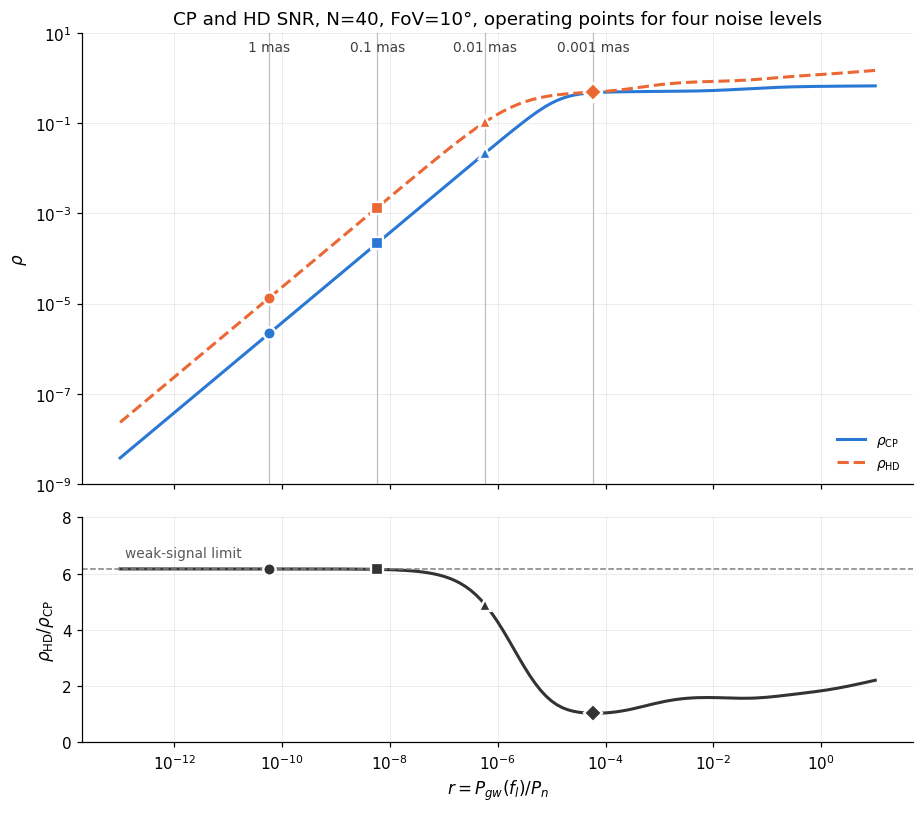

In [5]:
gD, g0D, lminD, lmaxD = make_field(N_DENSE, FOV)
r = np.logspace(-13, 1, 141)
t = time.time()
cpD = M.rho_cp_full(r, gD, lminD, lmaxD, verbose=False)
hdD = hd_rho(gD, g0D, r)
print(f"N={N_DENSE}: curves computed in {time.time()-t:.1f}s")

iu = np.triu_indices(N_DENSE, 1)
weak_ratio = np.sqrt(2 * np.sum(gD[iu]**2) / N_DENSE)
print(f"weak-signal ratio: analytic {weak_ratio:.3f}, numeric at r=1e-13 {hdD[0]/cpD[0]:.3f}, sqrt(N-1) = {np.sqrt(N_DENSE-1):.3f}")

rp = np.array([R_PHYS[s] for s in SIGMAS_MAS])
cp_op = M.rho_cp_full(rp, gD, lminD, lmaxD, verbose=False)
hd_op = hd_rho(gD, g0D, rp)
print(f"\n{'sigma [mas]':>12} {'r_phys':>10} {'rho_CP':>11} {'rho_HD':>11} {'HD/CP':>7} {'HD/CP vs weak limit':>20}")
for s, x, a, b in zip(SIGMAS_MAS, rp, cp_op, hd_op):
    print(f"{s:12g} {x:10.2e} {a:11.3e} {b:11.3e} {b/a:7.2f} {b/a/weak_ratio:20.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 7.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.loglog(r, cpD, color=CP_COL, ls="-", label=r"$\rho_{\rm CP}$")
ax1.loglog(r, hdD, color=HD_COL, ls="--", label=r"$\rho_{\rm HD}$")
for i, s in enumerate(SIGMAS_MAS):
    ax1.axvline(rp[i], color="0.75", lw=0.8, zorder=0)
    ax1.plot(rp[i], cp_op[i], MK[i], color=CP_COL, ms=8, mec="white", mew=1.5, zorder=5)
    ax1.plot(rp[i], hd_op[i], MK[i], color=HD_COL, ms=8, mec="white", mew=1.5, zorder=5)
    ax1.text(rp[i], 4, f"{s:g} mas", ha="center", fontsize=9, color="0.25")
ax1.set_ylim(1e-9, 10); ax1.set_ylabel(r"$\rho$"); ax1.legend(loc="lower right")
ax1.set_title(f"CP and HD SNR, N={N_DENSE}, FoV={FOV:g}°, operating points for four noise levels")
ax2.semilogx(r, hdD / cpD, color="0.2")
ax2.axhline(weak_ratio, color="0.5", lw=1, ls="--")
ax2.text(r[1], weak_ratio * 1.05, "weak-signal limit", fontsize=9, color="0.35", va="bottom")
for i in range(len(SIGMAS_MAS)):
    ax2.plot(rp[i], hd_op[i] / cp_op[i], MK[i], color="0.2", ms=8, mec="white", mew=1.5)
ax2.set_ylabel(r"$\rho_{\rm HD}/\rho_{\rm CP}$"); ax2.set_xlabel(r"$r=P_{gw}(f_l)/P_n$"); ax2.set_ylim(0, weak_ratio * 1.3)
plt.tight_layout(); plt.show()

**Reading.** The operating points at 1 and 0.1 mas both sit in the linear regime, where the ratio is pinned at its weak-signal value, so the separation does not change between them. Both SNRs grow by 100 (a factor of 10 in $\sigma$ gives 100 in $r$). The separation starts to shrink only once $r_{\rm phys}$ reaches the saturation region. HD saturates first because it has $\sim N^2/2$ pairs against CP's $N$ stars.

## 4. The same result in amplitude space

For each noise level, the SNR as a function of $A_{gw}$, with the NANOGrav-level amplitude marked. The vertical gap at the marker is the separation measured in Section 3.

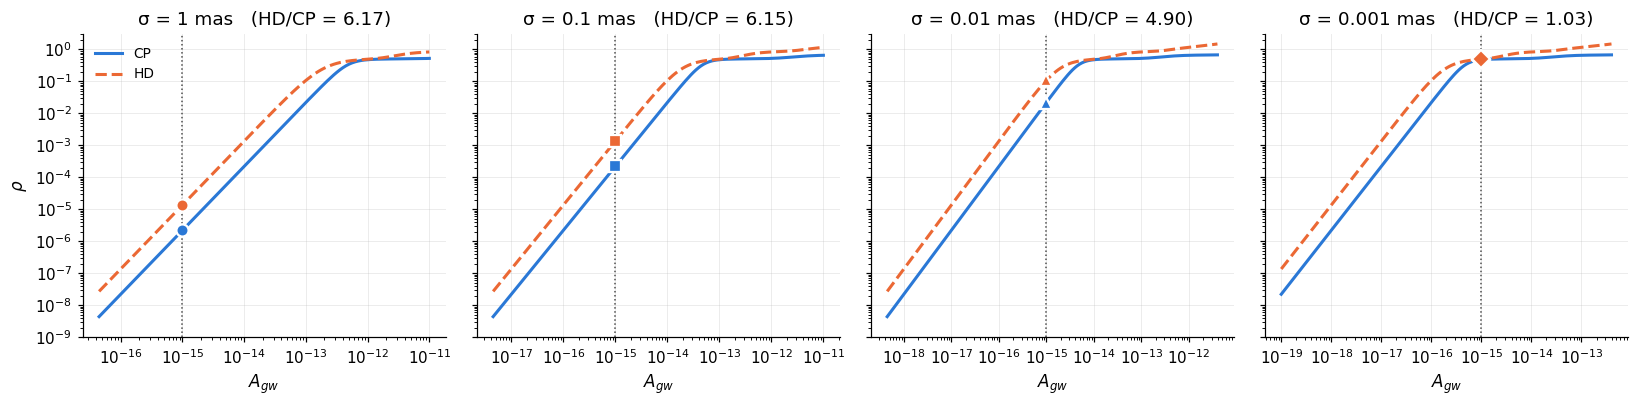

In [6]:
A_axis = np.logspace(-19, -11, 161)
fig, axs = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for i, s in enumerate(SIGMAS_MAS):
    rr = p_gw(A_axis) / noise_psd(s)
    ax = axs[i]
    ax.loglog(A_axis, np.interp(np.log10(rr), np.log10(r), cpD, left=np.nan, right=np.nan), color=CP_COL, ls="-", label="CP")
    ax.loglog(A_axis, np.interp(np.log10(rr), np.log10(r), hdD, left=np.nan, right=np.nan), color=HD_COL, ls="--", label="HD")
    ax.axvline(M.A_gw, color="0.3", lw=1, ls=":")
    ax.plot(M.A_gw, cp_op[i], MK[i], color=CP_COL, ms=8, mec="white", mew=1.5)
    ax.plot(M.A_gw, hd_op[i], MK[i], color=HD_COL, ms=8, mec="white", mew=1.5)
    ax.set_title(f"σ = {s:g} mas   (HD/CP = {hd_op[i]/cp_op[i]:.2f})")
    ax.set_xlabel(r"$A_{gw}$"); ax.set_ylim(1e-9, 3)
axs[0].set_ylabel(r"$\rho$"); axs[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

## 5. Production $N$

The same four operating points at `N_STARS` from `main.py`, using the pipeline functions directly: `rho_cp_full` (exact eigen-solution) and `rho_hd_full_matrix` (matrix-free MINRES, since the pair matrix is too large for a dense solve). Set `RUN_PRODUCTION_N = False` in the setup cell to skip this section.

In [7]:
if RUN_PRODUCTION_N:
    t = time.time()
    gP, g0P, lminP, lmaxP = make_field(N_PROD, FOV)
    print(f"N={N_PROD}: ell_max={lmaxP}, Gamma matrix in {time.time()-t:.0f}s")
    iuP = np.triu_indices(N_PROD, 1)
    weakP = np.sqrt(2 * np.sum(gP[iuP]**2) / N_PROD)
    cpP = M.rho_cp_full(rp, gP, lminP, lmaxP, verbose=False)
    hdP = H.rho_hd_full_matrix(rp, gP, g0P, verbose=False)
    print(f"weak-signal ratio (analytic) = {weakP:.2f}\n")
    print(f"{'sigma [mas]':>12} {'r_phys':>10} {'rho_CP':>11} {'rho_HD':>11} {'HD/CP':>7} {'HD/CP vs weak limit':>20}")
    for s, x, a, b in zip(SIGMAS_MAS, rp, cpP, hdP):
        print(f"{s:12g} {x:10.2e} {a:11.3e} {b:11.3e} {b/a:7.2f} {b/a/weakP:20.3f}")

N=500: ell_max=20480, Gamma matrix in 68s


weak-signal ratio (analytic) = 22.04

 sigma [mas]     r_phys      rho_CP      rho_HD   HD/CP  HD/CP vs weak limit
           1   5.86e-11   7.796e-06   1.718e-04   22.03                1.000
         0.1   5.86e-09   7.796e-04   1.661e-02   21.31                0.967
        0.01   5.86e-07   7.654e-02   3.877e-01    5.07                0.230
       0.001   5.86e-05   5.056e-01   7.008e-01    1.39                0.063


## Conclusions

1. **The SNR curves in $r$ do not depend on the noise level.** Built in physical units, the curves for 1, 0.1, 0.01 and 0.001 mas coincide when plotted against $r=P_{gw}/P_n$ (Section 2). The white noise enters only through $P_n$.
2. **The noise level sets the operating point.** $r_{\rm phys}=5.9\times10^{-11},\ 5.9\times10^{-9},\ 5.9\times10^{-7},\ 5.9\times10^{-5}$ for the four values, a factor of 100 per decade in $\sigma$.
3. **The separation at the operating point:**

| $\sigma$ [mas] | HD/CP, $N=40$ | HD/CP, $N=500$ |
|---|---|---|
| 1 | 6.17 | 22.0 |
| 0.1 | 6.15 | 21.3 |
| 0.01 | 4.90 | 5.07 |
| 0.001 | 1.03 | 1.39 |

4. **From 1 to 0.1 mas the separation is unchanged** (within 0.3% at $N=40$ and 3% at $N=500$) while both SNRs grow by 100. Both operating points lie in the linear regime, where the ratio is fixed at $\sqrt{(2/N)\sum_{a<b}\Gamma_{ab}^2}\approx\sqrt{N-1}\,\Gamma_{\rm rms}$. That limit depends on $N$ and the field, not on $\sigma$ or on the factor on $P_{ab}$.
5. **At 0.01 and 0.001 mas the separation collapses.** HD reaches its first plateau first (it has $\sim N^2/2$ pairs against $N$ stars), so it stops gaining while CP keeps rising, and at 0.001 mas both sit on their first plateaus at $\rho\approx0.5$ to $0.7$.
6. **Larger $N$ reaches the collapse at higher noise.** The HD saturation moves to lower $r$ as $N$ grows, so at $N=500$ the ratio has already dropped to 23% of its weak-signal value at 0.01 mas, against 79% at $N=40$.
7. In this setup, $\rho<1$ for both statistics at $A_{gw}=10^{-15}$ for every noise level tested (largest value 0.70, HD at 0.001 mas and $N=500$).